## Import packages

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import (
    add_moving_averages,
    add_rsi,
    add_macd,
    add_bollinger_bands,
    add_volume_features,
    add_lag_features,
    add_price_features,
    add_date_features,
    feature_engineering_pipeline
)
from src import (
    get_correlation_with_target,
    remove_highly_correlated,
    plot_feature_correlations,
    plot_correlation_matrix,
    select_features
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})
sns.set_palette("husl")

## Load cleaned data

In [2]:
df = pd.read_csv('../data/raw/cleaned_data.csv', index_col=0, parse_dates=True)
ticker = "AAPL"
print(f"Loaded cleaned data: {df.shape}")
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-03-15,120.765701,120.775443,117.288538,118.252799,92403800
2021-03-16,122.304626,123.911721,121.476732,122.431243,115227900
2021-03-17,121.515686,122.587080,119.158611,120.824150,111932600
2021-03-18,117.395668,119.976757,117.191130,119.684556,121229700
2021-03-19,116.869720,118.272276,116.567784,116.782064,185549500


## Run full feature engineering pipeline

In [3]:
df_features = feature_engineering_pipeline(df, include_ta=True)
df_features.head()

,Close,High,Low,Open,Volume,SMA_7,EMA_7,SMA_14,EMA_14,SMA_21,...,Close_Lag_5,Close_Lag_7,Daily_Return,High_Low_Range,Open_Close_Range,Price_Momentum,Day_of_Week,Month,Quarter,Week_of_Year
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-24,124.005119,124.824669,122.873369,122.941664,63092900,123.085212,123.204786,123.434550,123.857801,125.331956,...,123.195320,121.926987,0.013314,0.015736,0.008650,0.001971,0,5,2,21
2021-05-25,123.809967,125.195395,123.244088,124.707563,72009500,123.008550,123.356081,123.366059,123.851423,124.979253,...,121.809883,124.346596,-0.001574,0.015761,-0.007198,0.007863,1,5,2,21
2021-05-26,123.761185,124.288037,123.341655,123.868507,56575900,123.089388,123.457357,123.179988,123.839391,124.639537,...,121.653801,123.195320,-0.000394,0.007647,-0.000866,0.033233,2,5,2,21
2021-05-27,122.229424,124.531958,122.034297,123.361181,94625600,123.149323,123.150374,122.836419,123.624729,124.264447,...,124.209991,121.809883,-0.012377,0.020434,-0.009174,0.002480,3,5,2,21
2021-05-28,121.575729,122.736755,121.517193,122.512352,71311100,123.138169,122.756713,122.680315,123.351529,123.862866,...,122.375771,121.653801,-0.005348,0.010031,-0.007645,-0.022283,4,5,2,21


## View all available features

In [4]:
print(f"Total features: {df_features.shape[1]}\n")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:3d}. {col}")

Total features: 37

    1. Close
    2. High
    3. Low
    4. Open
    5. Volume
    6. SMA_7
    7. EMA_7
    8. SMA_14
    9. EMA_14
   10. SMA_21
   11. EMA_21
   12. SMA_50
   13. EMA_50
   14. RSI
   15. MACD
   16. MACD_Signal
   17. MACD_Hist
   18. BB_Upper
   19. BB_Middle
   20. BB_Lower
   21. BB_Width
   22. Volume_Change
   23. Volume_SMA_20
   24. Volume_Ratio
   25. Close_Lag_1
   26. Close_Lag_2
   27. Close_Lag_3
   28. Close_Lag_5
   29. Close_Lag_7
   30. Daily_Return
   31. High_Low_Range
   32. Open_Close_Range
   33. Price_Momentum
   34. Day_of_Week
   35. Month
   36. Quarter
   37. Week_of_Year


## Visualize moving averages

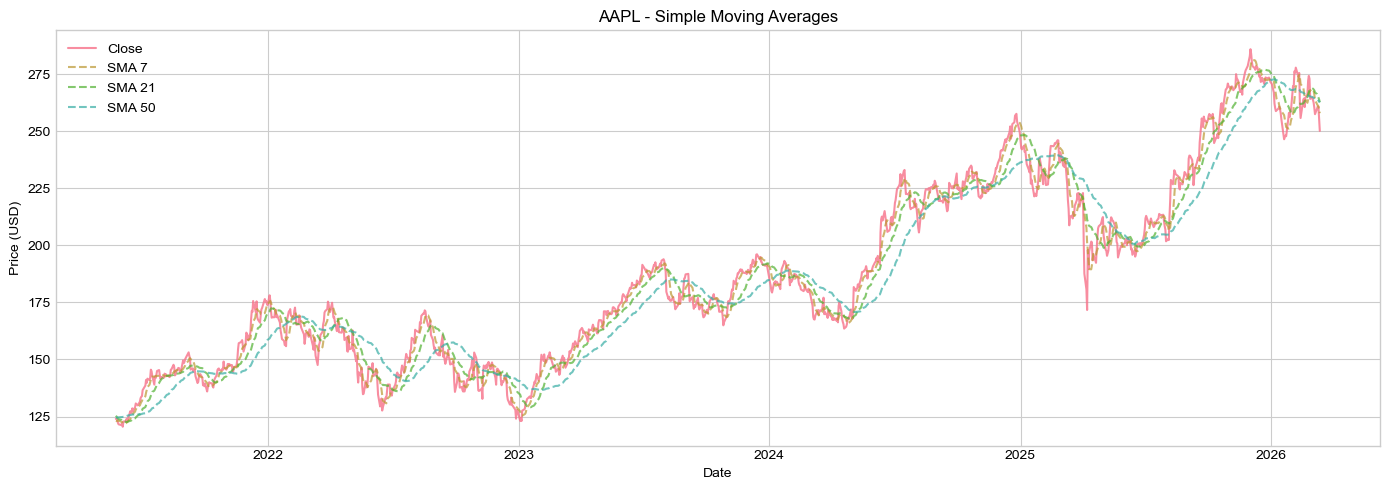

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_features['Close'], label='Close', alpha=0.8)
plt.plot(df_features['SMA_7'], label='SMA 7', linestyle='--', alpha=0.7)
plt.plot(df_features['SMA_21'], label='SMA 21', linestyle='--', alpha=0.7)
plt.plot(df_features['SMA_50'], label='SMA 50', linestyle='--', alpha=0.7)
plt.title(f'{ticker} - Simple Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Visualize RSI

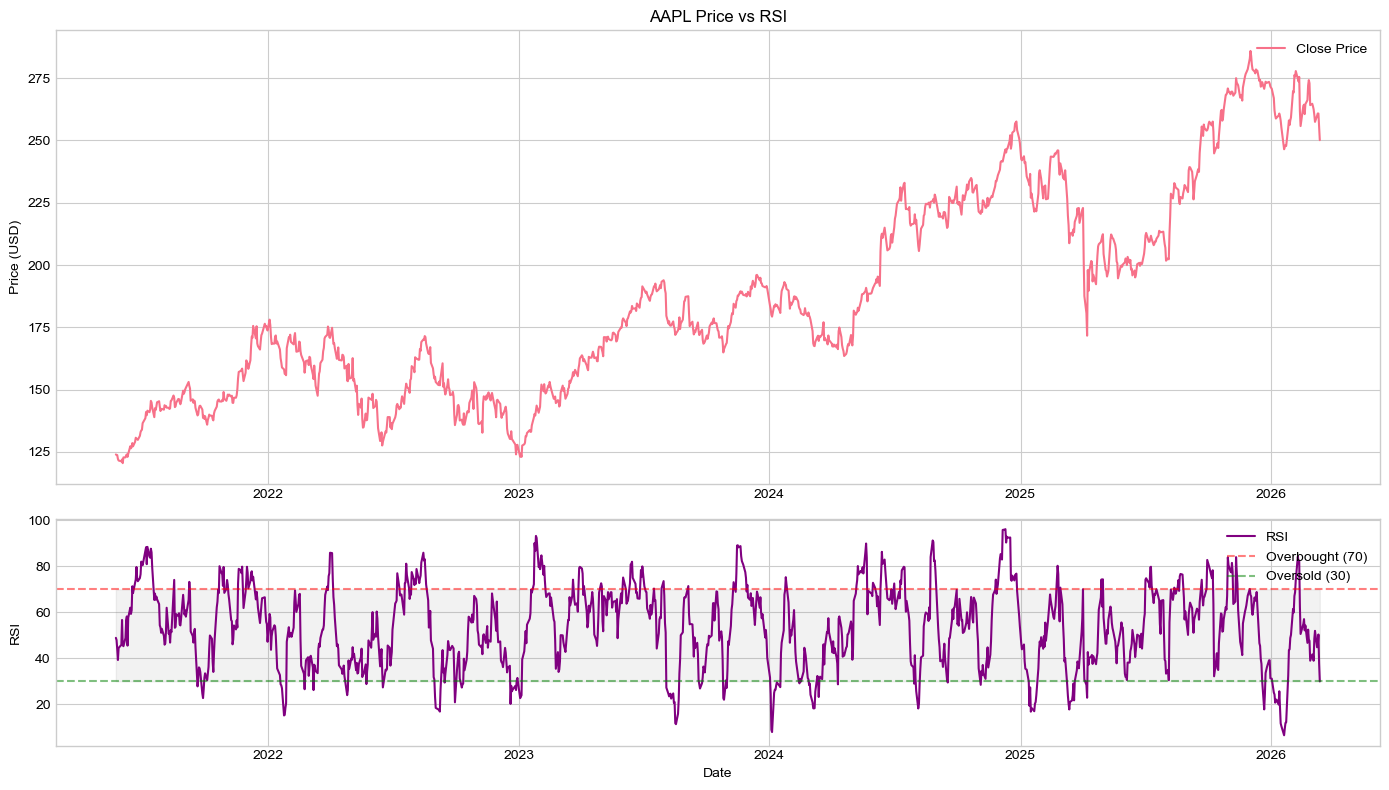

In [6]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df_features['Close'], label='Close Price')
axes[0].set_title(f'{ticker} Price vs RSI')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(df_features['RSI'], color='purple', label='RSI')
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].fill_between(df_features.index, 30, 70, alpha=0.1, color='gray')
axes[1].set_ylabel('RSI')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualize MACD

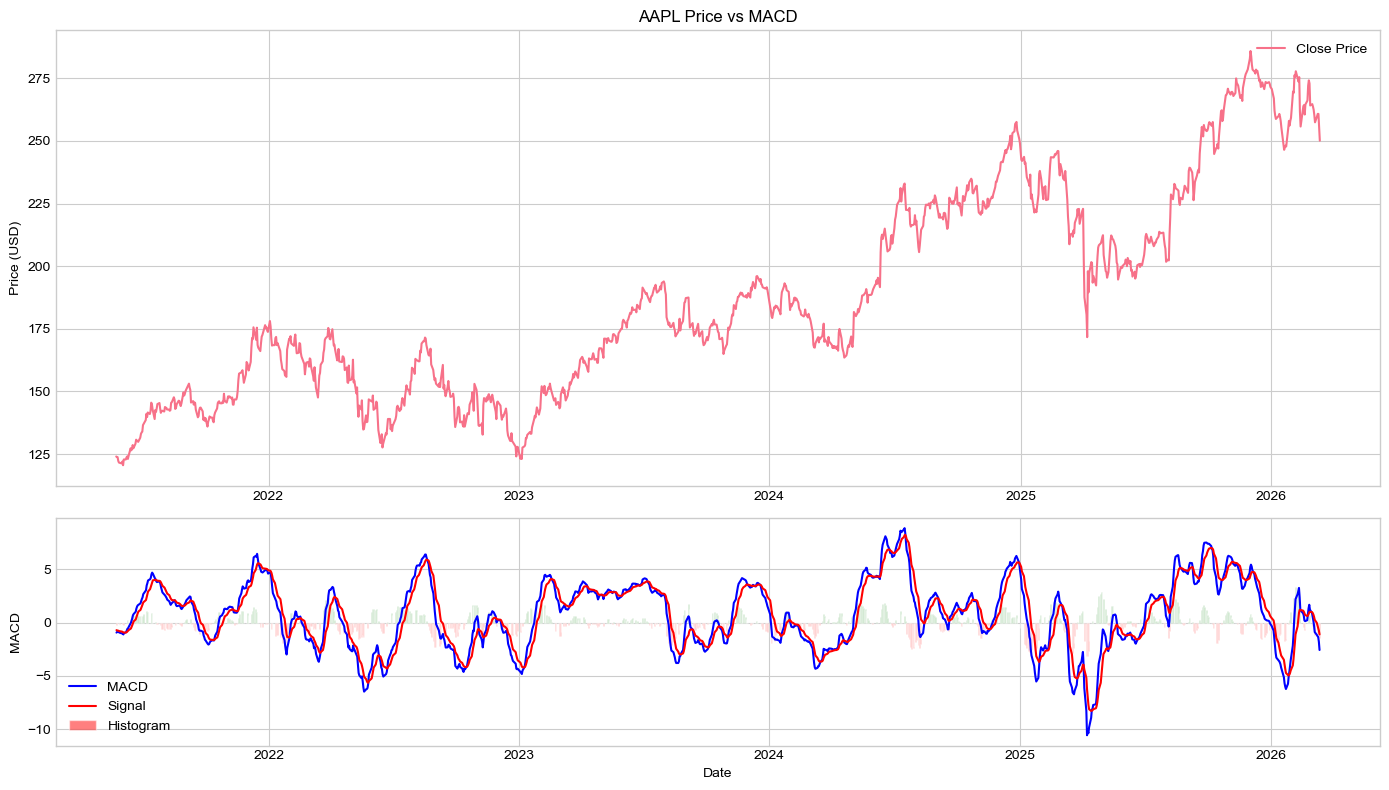

In [7]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df_features['Close'], label='Close Price')
axes[0].set_title(f'{ticker} Price vs MACD')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(df_features['MACD'], label='MACD', color='blue')
axes[1].plot(df_features['MACD_Signal'], label='Signal', color='red')
colors = ['green' if v >= 0 else 'red' for v in df_features['MACD_Hist']]
axes[1].bar(df_features.index, df_features['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
axes[1].set_ylabel('MACD')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualize Bollinger Bands

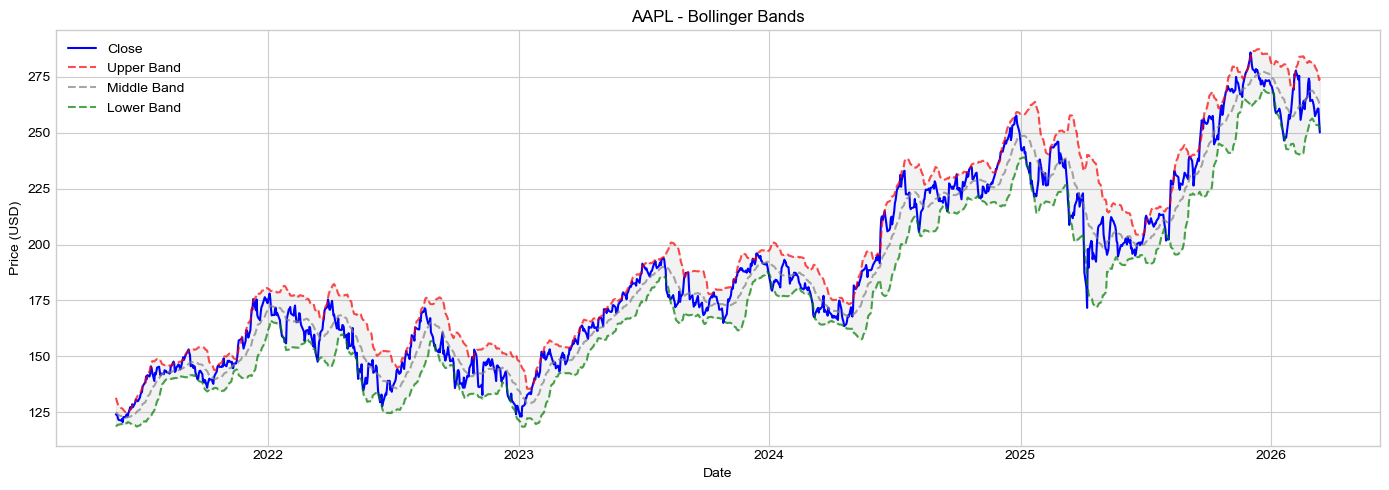

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df_features['Close'], label='Close', color='blue', linewidth=1.5)
plt.plot(df_features['BB_Upper'], label='Upper Band', color='red', linestyle='--', alpha=0.7)
plt.plot(df_features['BB_Middle'], label='Middle Band', color='gray', linestyle='--', alpha=0.7)
plt.plot(df_features['BB_Lower'], label='Lower Band', color='green', linestyle='--', alpha=0.7)
plt.fill_between(df_features.index, df_features['BB_Upper'], df_features['BB_Lower'], alpha=0.1, color='gray')
plt.title(f'{ticker} - Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Feature correlations with target

In [9]:

strong_correlations = get_correlation_with_target(df_features, target="Close", threshold=0.3)
print("\nTop correlated features:")
print(strong_correlations.head(20))

Features with |correlation| >= 0.3 to 'Close': 21

Top correlated features:
High             0.999033
Low              0.999015
Open             0.997786
Close_Lag_1      0.996938
EMA_7            0.996047
SMA_7            0.994004
Close_Lag_2      0.993541
EMA_14           0.991411
Close_Lag_3      0.990086
SMA_14           0.987857
EMA_21           0.987076
Close_Lag_5      0.983868
BB_Middle        0.983186
SMA_21           0.982426
Close_Lag_7      0.978200
BB_Upper         0.977369
BB_Lower         0.976508
EMA_50           0.970593
SMA_50           0.959508
Volume_SMA_20   -0.666162
Name: Close, dtype: float64


## Plot feature correlations

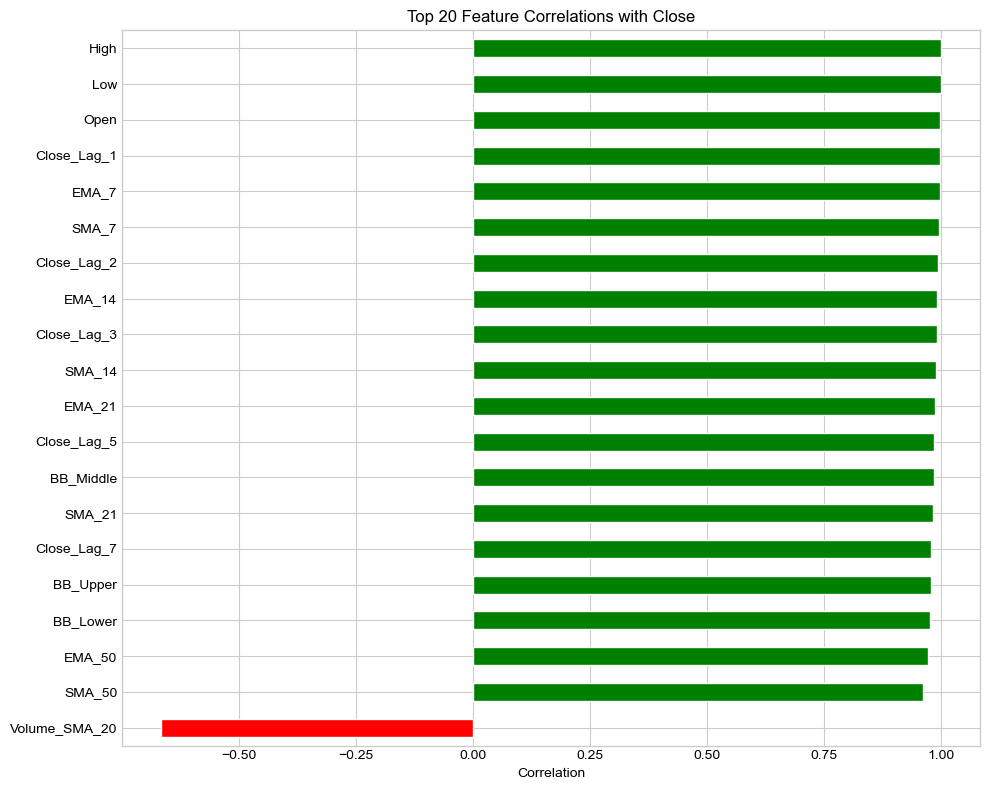

In [10]:
plot_feature_correlations(df_features, target="Close", top_n=20)

## Remove highly correlated features

In [11]:

df_reduced, dropped = remove_highly_correlated(
    df_features,
    threshold=0.95,
    protect_columns=["Close"]
)
print(f"\nFeatures before: {df_features.shape[1]}")
print(f"Features after: {df_reduced.shape[1]}")

Removed 21 highly correlated features (threshold=0.95)
Dropped: ['High', 'Low', 'Open', 'SMA_7', 'EMA_7', 'SMA_14', 'EMA_14', 'SMA_21', 'EMA_21', 'SMA_50', 'EMA_50', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_7', 'Quarter', 'Week_of_Year']

Features before: 37
Features after: 16


In [12]:
selected_features = select_features(
    df_features,
    target="Close",
    corr_threshold=0.2,          # was 0.3
    redundancy_threshold=0.90,   # was 0.95
    must_include=["Close"]
)

Starting feature selection pipeline...
----------------------------------------
Features with |correlation| >= 0.2 to 'Close': 23

Candidate features: 24
Removed 20 highly correlated features (threshold=0.9)
Dropped: ['High', 'Low', 'Open', 'Close_Lag_1', 'EMA_7', 'SMA_7', 'Close_Lag_2', 'EMA_14', 'Close_Lag_3', 'SMA_14', 'EMA_21', 'Close_Lag_5', 'BB_Middle', 'SMA_21', 'Close_Lag_7', 'BB_Upper', 'BB_Lower', 'EMA_50', 'SMA_50', 'MACD']
----------------------------------------
Final selected features (4):
  1. Close (corr: 1.000)
  2. Volume_SMA_20 (corr: -0.666)
  3. Volume (corr: -0.434)
  4. MACD_Signal (corr: 0.295)


## Correlation matrix of selected features

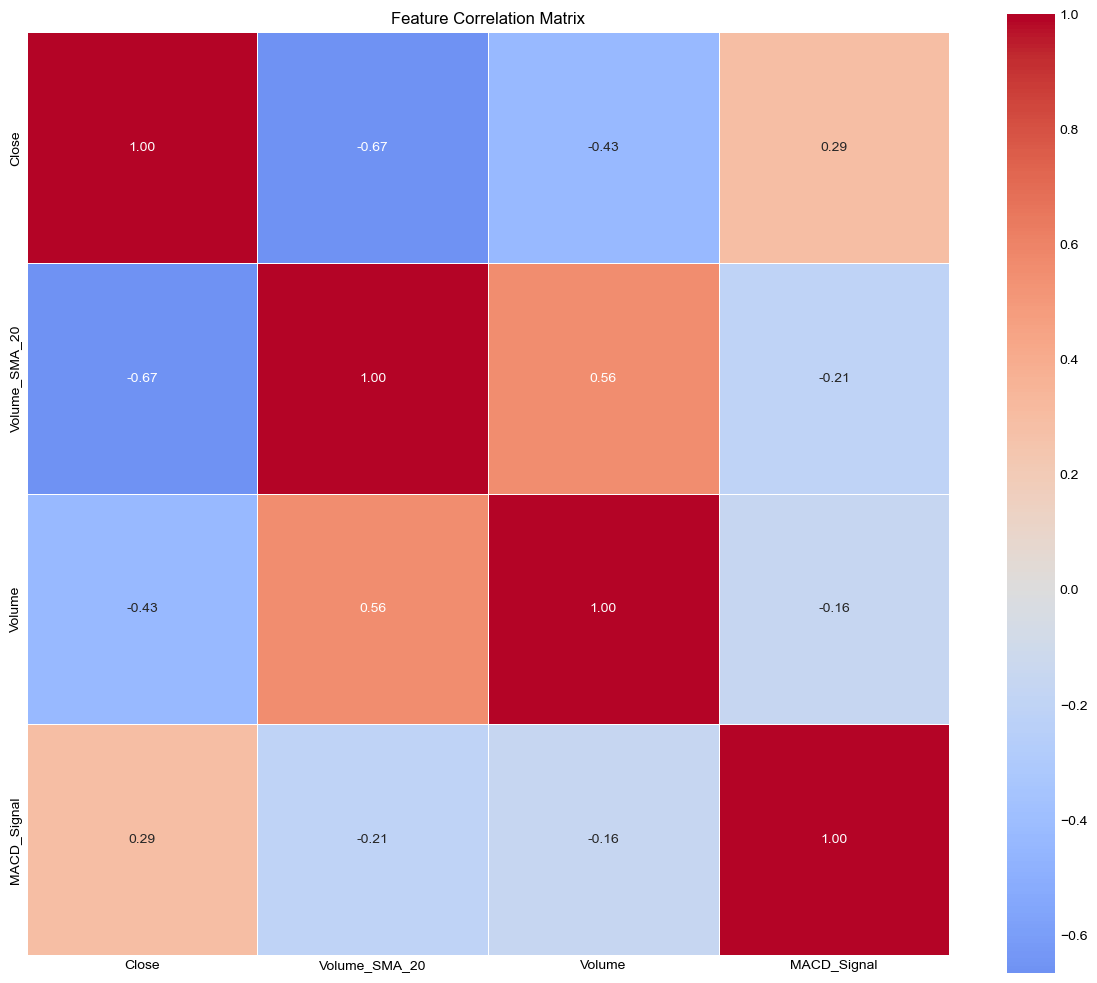

In [13]:
plot_correlation_matrix(df_features, features=selected_features)


## Save engineered data and selected features

In [14]:
import json

df_features.to_csv('../data/raw/featured_data.csv')

with open('../data/raw/selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)

print(f"Engineered data saved to ../data/raw/featured_data.csv")
print(f"Selected features saved to ../data/raw/selected_features.json")
print(f"Shape: {df_features.shape}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

Engineered data saved to ../data/raw/featured_data.csv
Selected features saved to ../data/raw/selected_features.json
Shape: (1207, 37)
Selected features (4): ['Close', 'Volume_SMA_20', 'Volume', 'MACD_Signal']


## Summary

In [15]:
print("=" * 50)
print(f"FEATURE ENGINEERING SUMMARY - {ticker}")
print("=" * 50)
print(f"Original features: {df.shape[1]}")
print(f"Engineered features: {df_features.shape[1]}")
print(f"Selected features: {len(selected_features)}")
print(f"Removed redundant: {len(dropped)}")
print(f"\nSelected features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f}")
print("=" * 50)
print("\nNext: 04_training.ipynb")

FEATURE ENGINEERING SUMMARY - AAPL
Original features: 5
Engineered features: 37
Selected features: 4
Removed redundant: 21

Selected features:
  1. Close
  2. Volume_SMA_20
  3. Volume
  4. MACD_Signal

Next: 04_training.ipynb
